<a href="https://www.kaggle.com/code/valeriolattarulo/lenet5-on-mnist-and-cifar?scriptVersionId=344762810" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This is an exercise wehre i replicate the CNN LENET-5 and trained it with the dataset MNIST, with input reshaped so to be of size 32x32, as in the paper "LeCun et al. (1998), Gradient-Based Learning Applied to Document Recognition" (https://hal.science/hal-03926082/document). The subsampling layers have been changed to ReLU followed by maxpool layer, which are the most widely used layers used today. I replaced RBF outputs + MSE/MAP criterion with a linear layer and cross-entropy loss. Ten epochs with a learning rate of 0.1 lead to 98.7-99.2% accuracy, with small variability in different trainings. After seeing the results of training, i tried several strategies to improve the accuracy of my models, these strategies include: data augmentation,TTA, normalization,batch-normalization and label smoothing


In [ ]:
from fastai.vision.all import *
import torch

In [ ]:
path=untar_data(URLs.MNIST)

In [ ]:
dls=ImageDataLoaders.from_folder(path,img_cls=PILImageBW,train='training',valid='testing',item_tfms=Resize(32))

In [ ]:
lenet5=nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(6,16,kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16,120,kernel_size=5),
    nn.ReLU(),
    Flatten(),
    nn.Linear(120,84),
    nn.ReLU(),
    nn.Linear(84,10),
)

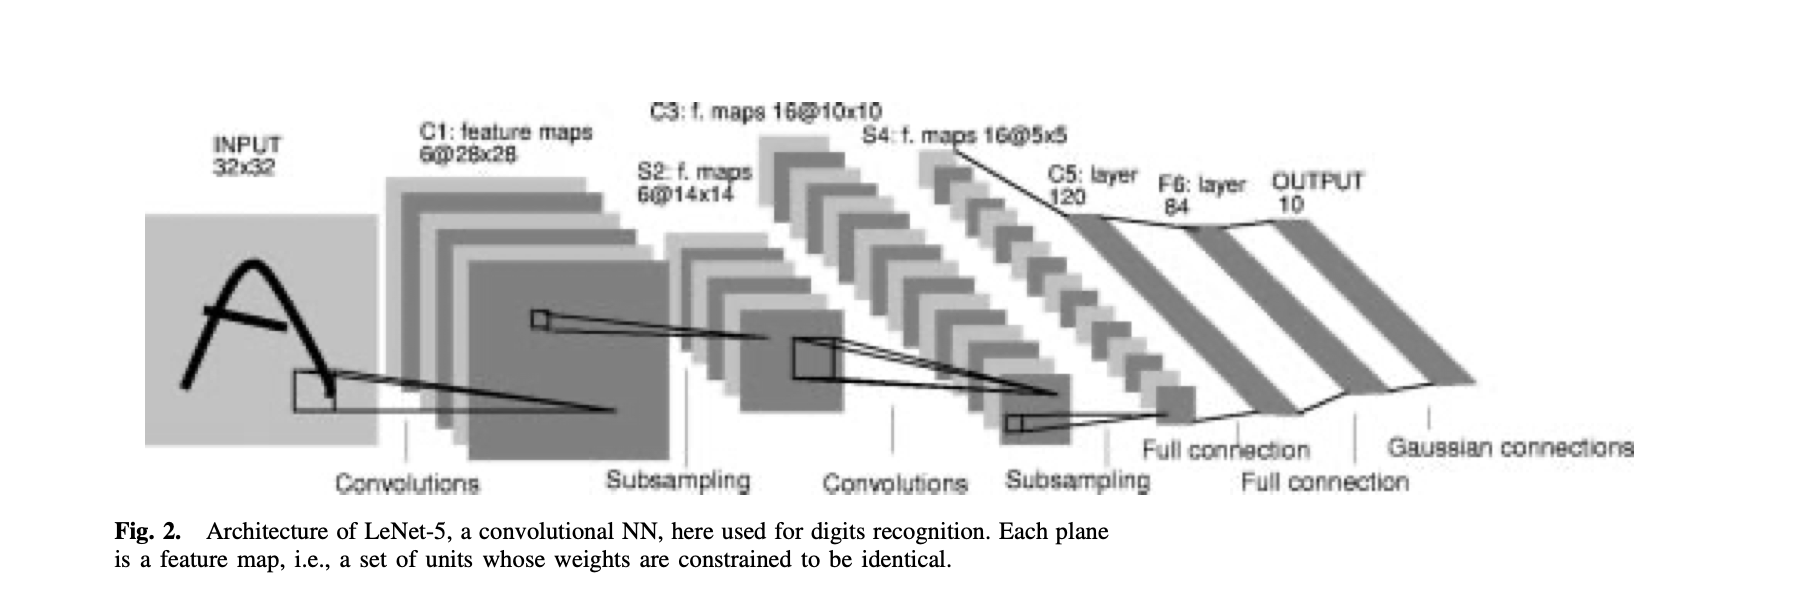

In [ ]:
learn_net=Learner(dls,opt_func=SGD,model=lenet5,loss_func=nn.CrossEntropyLoss(),metrics=accuracy)

In [ ]:
lr=0.1
learn_net.fit(10,0.1)

now i will try normalization of mean and standard deviation. neural networks work well with mean 0 and std 1

In [ ]:
dls=ImageDataLoaders.from_folder(path,img_cls=PILImageBW,train='training',valid='testing',item_tfms=Resize(32),batch_tfms=Normalize.from_stats(mean=0.1277, std=0.2851))

In [ ]:
learn_net=Learner(dls,opt_func=SGD,model=lenet5,loss_func=nn.CrossEntropyLoss(),metrics=accuracy)

In [ ]:
lr=0.1
learn_net.fit(10,0.1)

I now train and test lenet on CIFAR dataset

In [ ]:
path_cifar=untar_data(URLs.CIFAR)

In [ ]:
dls_cifar=ImageDataLoaders.from_folder(path_cifar,img_cls=PILImage,train='train',valid='test',item_tfms=Resize(32))


In [ ]:
lenet5_cifar=nn.Sequential(
    nn.Conv2d(3,6,kernel_size=5),
    nn.BatchNorm2d(6),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(6,16,kernel_size=5),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16,120,kernel_size=5),
    nn.BatchNorm2d(120),
    nn.ReLU(),
    Flatten(),
    nn.Linear(120,84),
    nn.ReLU(),
    nn.Linear(84,10),
)

In [ ]:
learn_net_cifar=Learner(dls_cifar,opt_func=SGD,model=lenet5_cifar,loss_func=nn.CrossEntropyLoss(),metrics=accuracy)

CIFAR is a more challenging dataset for our lenet5, presumably because images are coloured and more complex.  accuracy after ten epochs was around 58%. Data augmentation and TTA lead to identical results. Batch normalization instead lead to a major improvement, from 58% to 67-68%%.

In [ ]:
lr=0.01
learn_net_cifar.fit_one_cycle(10,0.1)

we notice a pattern suggestive of overfitting: valid loss stays constant while train loss keeps decreasing

In [ ]:
preds,targs=learn_net_cifar.tta()
accuracy(preds,targs).item()

trying TTA didn't change accuracy at all

In [ ]:
learn_net_cifa=Learner(dls_cifar,opt_func=SGD,model=lenet5_cifar,loss_func=LabelSmoothingCrossEntropy(),metrics=accuracy)

In [ ]:
lr=0.01
learn_net_cifar.fit_one_cycle(10,0.1)

labels moothing improved minimally accuracy
